In [35]:
import pandas as pd

file_path = "DATASET.xlsx"

orders      = pd.read_excel(file_path, sheet_name="orders")
order_items = pd.read_excel(file_path, sheet_name="order_items")
payments    = pd.read_excel(file_path, sheet_name="order_payments")
reviews     = pd.read_excel(file_path, sheet_name="order_reviews")
customers   = pd.read_excel(file_path, sheet_name="customers")
products    = pd.read_excel(file_path, sheet_name="products")
sellers     = pd.read_excel(file_path, sheet_name="sellers")
geolocation = pd.read_excel(file_path, sheet_name="geolocation")
cat_translation = pd.read_excel(file_path, sheet_name="category_translation")

for name, df in [("orders",orders),("order_items",order_items),("payments",payments),
                  ("reviews",reviews),("customers",customers),("products",products),
                  ("sellers",sellers),("geolocation",geolocation),("cat_translation",cat_translation)]:
    print(name, df.shape)

orders (99441, 8)
order_items (112650, 6)
payments (103886, 5)
reviews (100000, 7)
customers (99441, 5)
products (32951, 9)
sellers (3095, 4)
geolocation (1000163, 5)
cat_translation (71, 2)


In [36]:
import os
os.makedirs("data", exist_ok=True)

orders.to_pickle("data/orders.pkl")
order_items.to_pickle("data/order_items.pkl")
payments.to_pickle("data/payments.pkl")
reviews.to_pickle("data/reviews.pkl")
customers.to_pickle("data/customers.pkl")
products.to_pickle("data/products.pkl")
sellers.to_pickle("data/sellers.pkl")
geolocation.to_pickle("data/geolocation.pkl")
cat_translation.to_pickle("data/cat_translation.pkl")

## 1. Data Understanding & Cleaning

In [37]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

print(orders[date_cols].isna().sum())
print(orders['order_status'].value_counts())

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [38]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders = delivered_orders.dropna(subset=['order_delivered_customer_date'])
print("Delivered orders with valid delivery date:", delivered_orders.shape[0])

Delivered orders with valid delivery date: 96470


In [39]:
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']
).dt.days

delivered_orders['delivery_delta_vs_estimate'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']
).dt.days
# positive = late, negative = early, 0 = on the exact estimated date

delivered_orders['is_late'] = delivered_orders['delivery_delta_vs_estimate'] > 0

In [40]:
products = products.merge(cat_translation, on='product_category_name', how='left')

In [41]:
items_full = order_items.merge(products, on='product_id', how='left') \
                         .merge(sellers, on='seller_id', how='left')

In [42]:
order_payment_summary = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    n_payments=('payment_sequential', 'count'),
    main_payment_type=('payment_type', lambda x: x.mode()[0] if not x.mode().empty else None),
    max_installments=('payment_installments', 'max')
).reset_index()

In [43]:
print("Duplicate order_ids in reviews:", reviews['order_id'].duplicated().sum())

reviews_dedup = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')

Duplicate order_ids in reviews: 559


In [44]:
master = orders.merge(customers, on='customer_id', how='left') \
               .merge(order_payment_summary, on='order_id', how='left') \
               .merge(reviews_dedup[['order_id','review_score','review_comment_title',
                                       'review_comment_message','review_creation_date',
                                       'review_answer_timestamp']], on='order_id', how='left')

# Add item-level aggregates per order (price, freight, category — an order can have multiple items)
order_item_agg = items_full.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    n_items=('order_item_id', 'count'),
    main_category=('product_category_name_english', lambda x: x.mode()[0] if not x.mode().empty else None)
).reset_index()

master = master.merge(order_item_agg, on='order_id', how='left')

print(master.shape)
master.head()

(99441, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,max_installments,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,total_price,total_freight,n_items,main_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,29.99,8.72,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,118.70,22.76,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,3.0,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58,159.90,19.22,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,1.0,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,45.00,27.20,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,1.0,5,NaN,NaN,2018-02-17,2018-02-18 13:02:51,19.90,8.72,1.0,stationery


In [46]:
master = master.merge(
    delivered_orders[['order_id','delivery_days','delivery_delta_vs_estimate','is_late']],
    on='order_id', how='left'
)

In [45]:
print(master.shape)
print(master.isna().sum())

(99441, 25)
order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  160
order_delivered_carrier_date      1783
order_delivered_customer_date     2965
order_estimated_delivery_date        0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
total_payment_value                  1
n_payments                           1
main_payment_type                    1
max_installments                     1
review_score                         0
review_comment_title             87745
review_comment_message           57896
review_creation_date                 0
review_answer_timestamp              0
total_price                        775
total_freight                      775
n_items                            775
main_category                     2185
dtype: int64


## 2. Exploratory Data Analysis


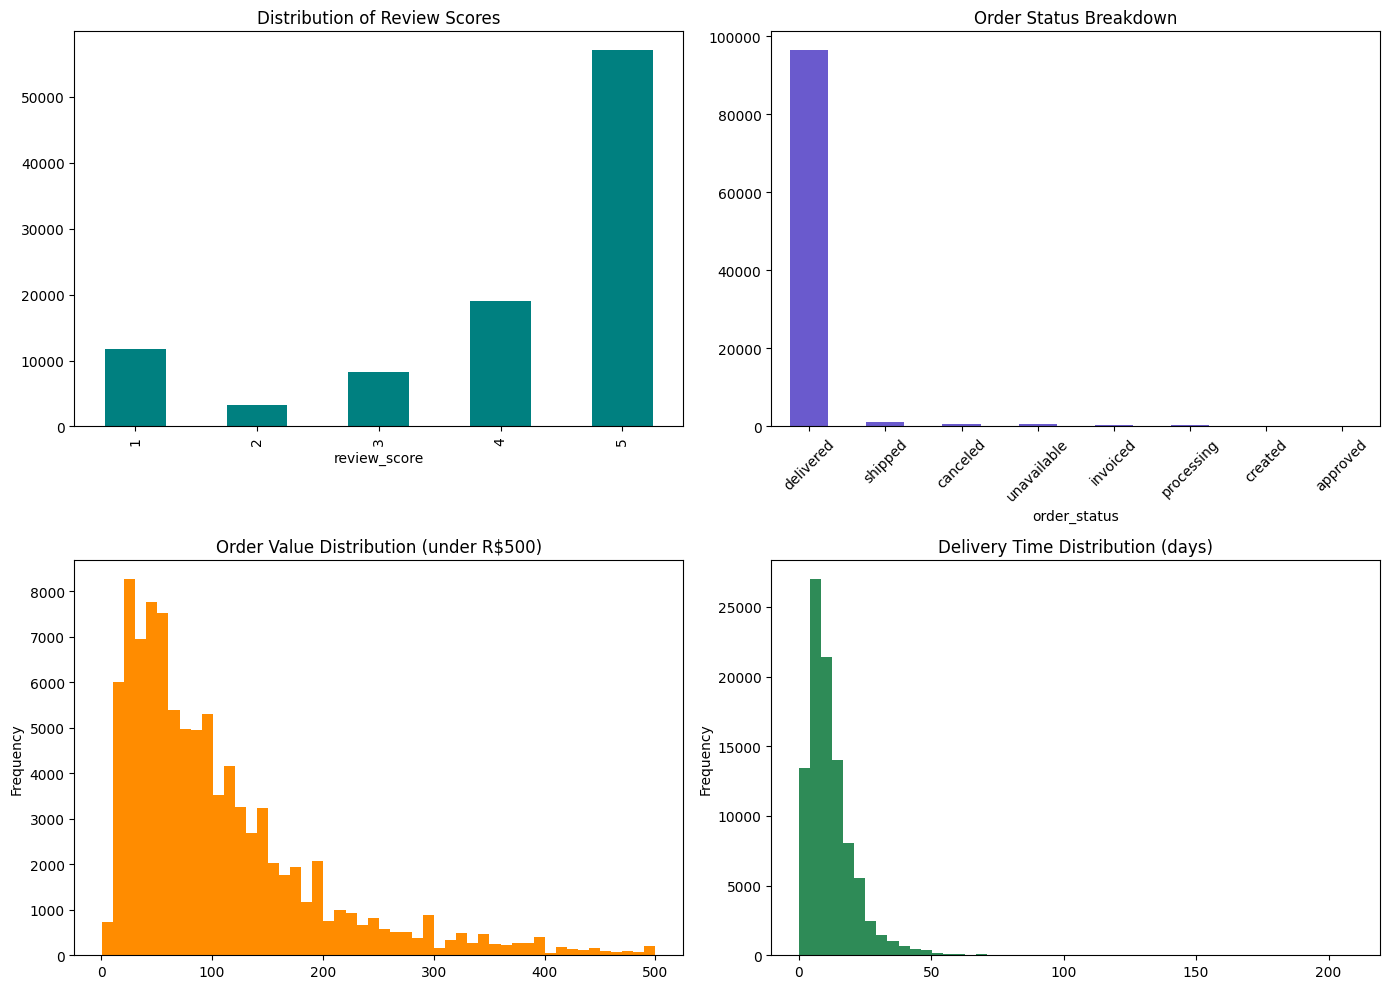

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

master['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='teal')
axes[0,0].set_title('Distribution of Review Scores')

master['order_status'].value_counts().plot(kind='bar', ax=axes[0,1], color='slateblue')
axes[0,1].set_title('Order Status Breakdown')
axes[0,1].tick_params(axis='x', rotation=45)

master[master['total_price'] < 500]['total_price'].plot(kind='hist', bins=50, ax=axes[1,0], color='darkorange')
axes[1,0].set_title('Order Value Distribution (under R$500)')

master['delivery_days'].dropna().plot(kind='hist', bins=50, ax=axes[1,1], color='seagreen')
axes[1,1].set_title('Delivery Time Distribution (days)')

plt.tight_layout()
plt.show()

## 3. Core Question Analysis
### 3.1 Core Question 1: Marketplace Performance Over Time

In [48]:
master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_trends = master.groupby('order_month').agg(
    order_volume=('order_id', 'count'),
    revenue=('total_price', 'sum'),
    avg_review_score=('review_score', 'mean')
).reset_index()

print(monthly_trends.tail(15))

   order_month  order_volume     revenue  avg_review_score
10     2017-08          4331   573971.68          4.226276
11     2017-09          4285   624401.69          4.172929
12     2017-10          4631   664219.43          4.105593
13     2017-11          7544  1010271.37          3.894088
14     2017-12          5673   743914.17          3.996122
15     2018-01          7269   950030.36          4.022286
16     2018-02          6728   844178.71          3.808264
17     2018-03          7211   983213.44          3.734295
18     2018-04          6939   996647.75          4.147283
19     2018-05          6873   996517.68          4.184054
20     2018-06          6167   865124.31          4.269661
21     2018-07          6292   895507.22          4.246186
22     2018-08          6512   854686.33          4.247082
23     2018-09            16      145.00          1.750000
24     2018-10             4        0.00          2.250000


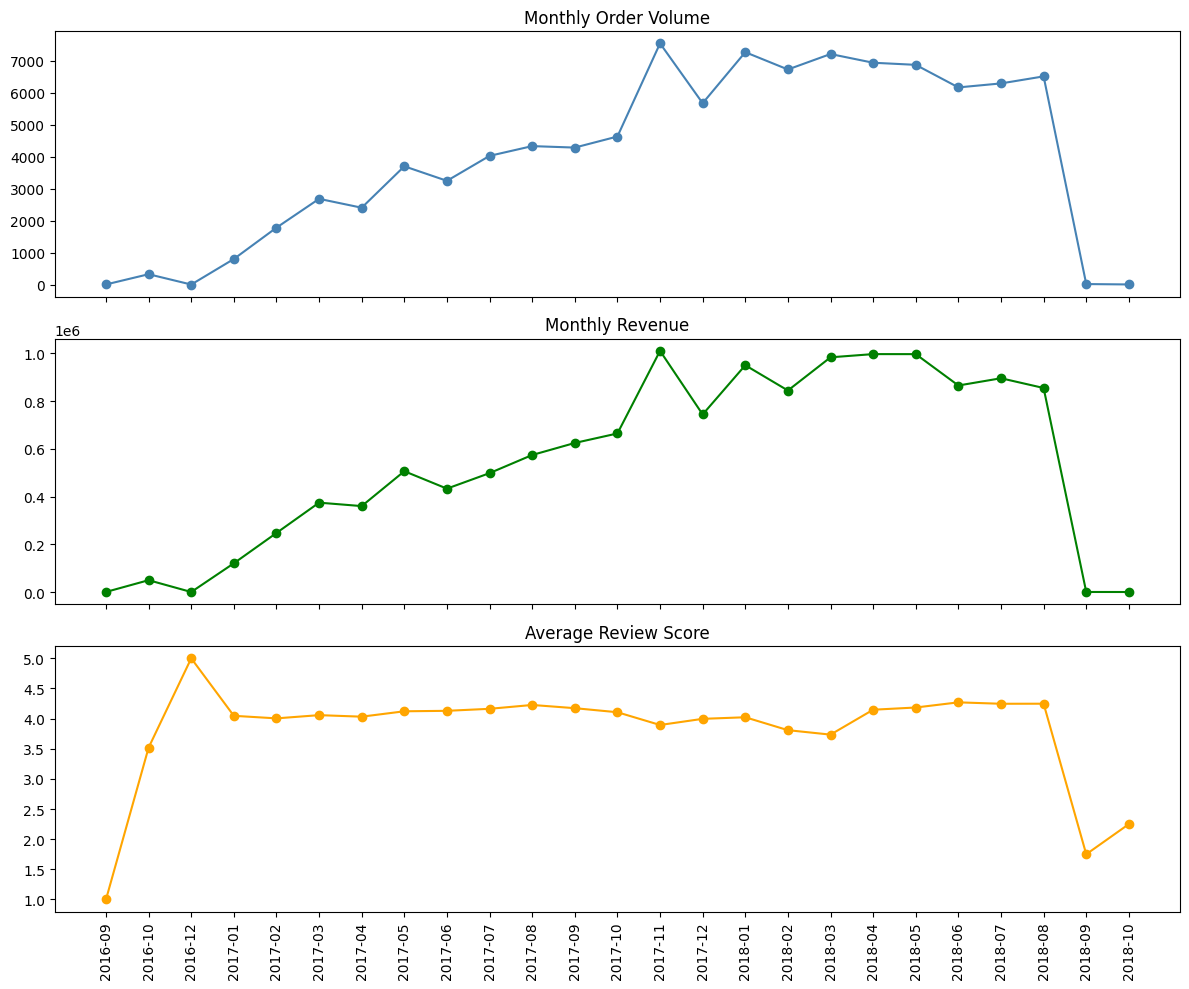

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly_trends['order_month'], monthly_trends['order_volume'], marker='o', color='steelblue')
axes[0].set_title('Monthly Order Volume')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(monthly_trends['order_month'], monthly_trends['revenue'], marker='o', color='green')
axes[1].set_title('Monthly Revenue')
axes[1].tick_params(axis='x', rotation=90)

axes[2].plot(monthly_trends['order_month'], monthly_trends['avg_review_score'], marker='o', color='orange')
axes[2].set_title('Average Review Score')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### 3.2 Core Question 2: Delivery Performance and Customer Satisfaction


In [50]:
delivered = master[master['order_status'] == 'delivered'].dropna(subset=['delivery_delta_vs_estimate', 'review_score']).copy()

# Overall average review score: late vs on-time
late_vs_score = delivered.groupby('is_late').agg(
    avg_review_score=('review_score', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

print(late_vs_score)

   is_late  avg_review_score  order_count
0    False          4.279488        89936
1     True          2.255280         6534


In [51]:
# Bucket delivery delta into ranges for a cleaner view
def delay_bucket(days):
    if days <= -7:
        return "Very Early (7+ days)"
    elif days < 0:
        return "Early (1-6 days)"
    elif days == 0:
        return "On Time"
    elif days <= 7:
        return "Late (1-7 days)"
    else:
        return "Very Late (7+ days)"

delivered['delay_bucket'] = delivered['delivery_delta_vs_estimate'].apply(delay_bucket)

bucket_order = ["Very Early (7+ days)", "Early (1-6 days)", "On Time", "Late (1-7 days)", "Very Late (7+ days)"]
delay_score = delivered.groupby('delay_bucket')['review_score'].mean().reindex(bucket_order)

print(delay_score)

delay_bucket
Very Early (7+ days)    4.302561
Early (1-6 days)        4.166827
On Time                 4.010062
Late (1-7 days)         2.695261
Very Late (7+ days)     1.690776
Name: review_score, dtype: float64


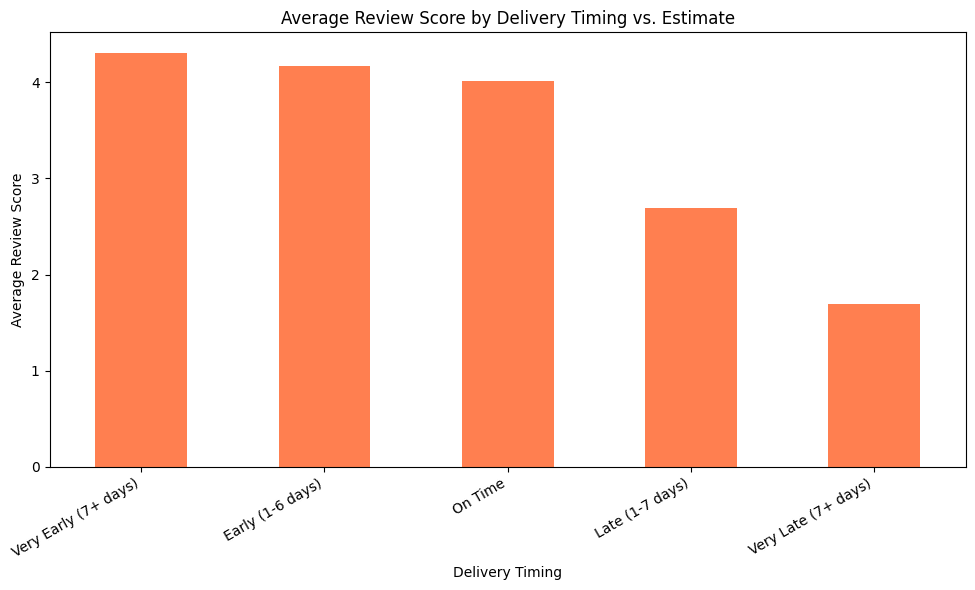

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
delay_score.plot(kind='bar', color='coral')
plt.title('Average Review Score by Delivery Timing vs. Estimate')
plt.ylabel('Average Review Score')
plt.xlabel('Delivery Timing')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

is_late                   False     True 
main_category                            
auto                   4.282270  2.287770
bed_bath_table         4.124781  2.204644
computers_accessories  4.198787  2.251799
furniture_decor        4.193162  2.336323
health_beauty          4.375439  2.322034
housewares             4.302443  2.253247
sports_leisure         4.372423  2.146045
telephony              4.173545  2.450172
toys                   4.373898  2.091286
watches_gifts          4.269467  2.182266


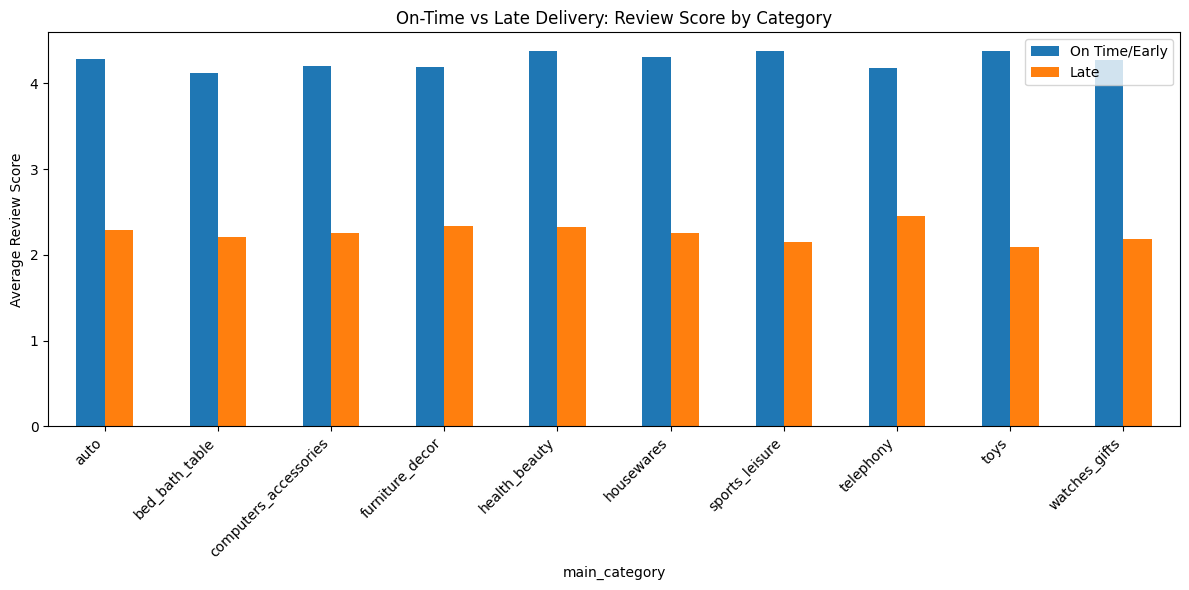

In [53]:
top_categories = master['main_category'].value_counts().head(10).index

cat_delay = delivered[delivered['main_category'].isin(top_categories)].groupby(
    ['main_category', 'is_late']
)['review_score'].mean().unstack()

print(cat_delay)

cat_delay.plot(kind='bar', figsize=(12,6))
plt.title('On-Time vs Late Delivery: Review Score by Category')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45, ha='right')
plt.legend(['On Time/Early', 'Late'])
plt.tight_layout()
plt.show()

In [54]:
state_delay = delivered.groupby(['customer_state', 'is_late'])['review_score'].mean().unstack()
state_delay['gap'] = state_delay[True] - state_delay[False] if True in state_delay.columns else None

print(state_delay.sort_values('gap'))

is_late            False      True       gap
customer_state                              
RN              4.374419  1.750000 -2.624419
AC              4.181818  1.666667 -2.515152
RR              4.194444  1.800000 -2.394444
SE              4.253521  1.921569 -2.331952
RJ              4.227729  1.909030 -2.318699
AM              4.297872  2.000000 -2.297872
DF              4.254332  1.974576 -2.279756
PE              4.287500  2.013072 -2.274428
PA              4.140476  1.905660 -2.234816
CE              4.241160  2.034091 -2.207070
AL              4.298077  2.094118 -2.203959
RS              4.307432  2.203077 -2.104355
MS              4.358610  2.294118 -2.064492
GO              4.225260  2.171875 -2.053385
PI              4.258537  2.242424 -2.016112
MA              4.163851  2.152000 -2.011851
PB              4.265659  2.314815 -1.950844
SC              4.275576  2.343643 -1.931933
MG              4.267374  2.342967 -1.924407
BA              4.131818  2.313131 -1.818687
MT        

### Insight: Delivery Timing is the Strongest Driver of Satisfaction

Delivery timing is the single strongest observed driver of customer satisfaction on Olist.
Late deliveries drop average review score from ~4.28 to ~2.26 — a pattern that holds
consistently across every major product category and is even more pronounced in specific
states (RN, AC, RR, SE), suggesting logistics performance, not product quality, is the
primary lever for improving customer experience.

### 3.3 Core Question 3: Seller and Geographic Patterns


In [55]:
print("Top 10 seller states:")
print(sellers['seller_state'].value_counts().head(10))
print()
print("Top 10 customer states:")
print(customers['customer_state'].value_counts().head(10))

Top 10 seller states:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64

Top 10 customer states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


In [56]:
state_summary = master.groupby('customer_state').agg(
    order_count=('order_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    avg_freight=('total_freight', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean')
).sort_values('order_count', ascending=False)

print(state_summary)

                order_count  avg_review_score  avg_freight  avg_delivery_days  \
customer_state                                                                  
SP                    41746          4.159848    17.370950           8.298094   
RJ                    12852          3.855742    23.945252          14.848583   
MG                    11635          4.120155    23.462704          11.542188   
RS                     5466          4.124588    24.948958          14.819237   
PR                     5045          4.168880    23.579768          11.526711   
SC                     3637          4.058015    24.822885          14.475183   
BA                     3380          3.834911    29.826289          18.866400   
DF                     2140          4.055140    23.823765          12.509135   
ES                     2033          4.005411    24.575111          15.331830   
GO                     2020          4.028218    26.464863          15.150741   
PE                     1652 

In [57]:
# Get seller state per order (using first item's seller if multiple)
order_seller_state = items_full.merge(orders[['order_id']], on='order_id') \
    .groupby('order_id')['seller_state'].first().reset_index()

master2 = master.merge(order_seller_state, on='order_id', how='left')
master2['cross_state'] = master2['customer_state'] != master2['seller_state']

cross_state_summary = master2.dropna(subset=['seller_state']).groupby('cross_state').agg(
    avg_review_score=('review_score', 'mean'),
    avg_freight=('total_freight', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    order_count=('order_id', 'count')
)
print(cross_state_summary)

             avg_review_score  avg_freight  avg_delivery_days  order_count
cross_state                                                               
False                4.194910    15.459095           7.482409        35483
True                 4.030008    26.959379          14.684579        63183


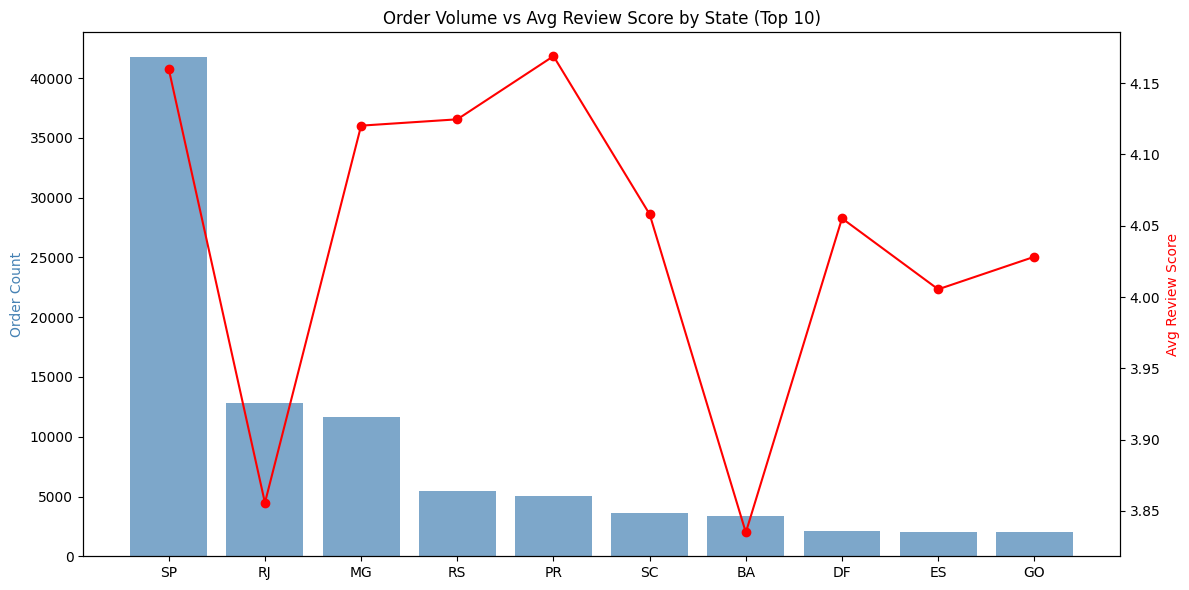

In [58]:
import matplotlib.pyplot as plt

top10_states = state_summary.head(10)

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(top10_states.index, top10_states['order_count'], color='steelblue', alpha=0.7)
ax1.set_ylabel('Order Count', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(top10_states.index, top10_states['avg_review_score'], color='red', marker='o')
ax2.set_ylabel('Avg Review Score', color='red')

plt.title('Order Volume vs Avg Review Score by State (Top 10)')
plt.tight_layout()
plt.show()

### Insight: Seller Concentration in São Paulo Creates a Geographic Satisfaction Gap

Sellers on Olist are heavily concentrated in São Paulo (~60% of all sellers), while customers
are spread more broadly across Brazil. This mismatch means the majority of orders (63,183 of
~98,600) ship cross-state, and cross-state orders take nearly double the delivery time
(14.7 vs 7.5 days), cost ~75% more in freight (R$26.96 vs R$15.46), and score lower on
satisfaction (4.03 vs 4.19). States farthest from the seller hub — RJ and BA in particular —
show both the slowest delivery and the lowest review scores, reinforcing that geographic
distance from sellers is a structural driver of the delivery delays identified in Q2.

#Section 3.4 — Core Question 4: Product Category Performance

In [59]:
cat_perf = items_full.merge(reviews_dedup[['order_id','review_score']], on='order_id', how='left').groupby(
    'product_category_name_english'
).agg(
    order_volume=('order_id', 'count'),
    avg_price=('price', 'mean'),
    total_revenue=('price', 'sum'),
    avg_review_score=('review_score', 'mean')
).sort_values('order_volume', ascending=False)

print("Top 15 categories by volume:")
print(cat_perf.head(15))

print("\nPlatform averages:")
print("avg_price:", items_full['price'].mean().round(2))
print("avg_review_score:", cat_perf['avg_review_score'].mean().round(2))

cat_perf_filtered = cat_perf[cat_perf['order_volume'] >= 30]  # avoid tiny-sample noise

print("\nBest 10 categories by avg review score (min 30 orders):")
print(cat_perf_filtered.sort_values('avg_review_score', ascending=False).head(10)[['order_volume','avg_review_score']])

print("\nWorst 10 categories by avg review score (min 30 orders):")
print(cat_perf_filtered.sort_values('avg_review_score').head(10)[['order_volume','avg_review_score']])

Top 15 categories by volume:
                               order_volume   avg_price  total_revenue  \
product_category_name_english                                            
bed_bath_table                        11115   93.296327     1036988.68   
health_beauty                          9670  130.163531     1258681.34   
sports_leisure                         8641  114.344285      988048.97   
furniture_decor                        8334   87.564494      729762.49   
computers_accessories                  7827  116.513903      911954.32   
housewares                             6964   90.788148      632248.66   
watches_gifts                          5991  201.135984     1205005.68   
telephony                              4545   71.213978      323667.53   
garden_tools                           4347  111.630196      485256.46   
auto                                   4235  139.957523      592720.11   
toys                                   4117  117.548360      483946.60   
cool_stuf

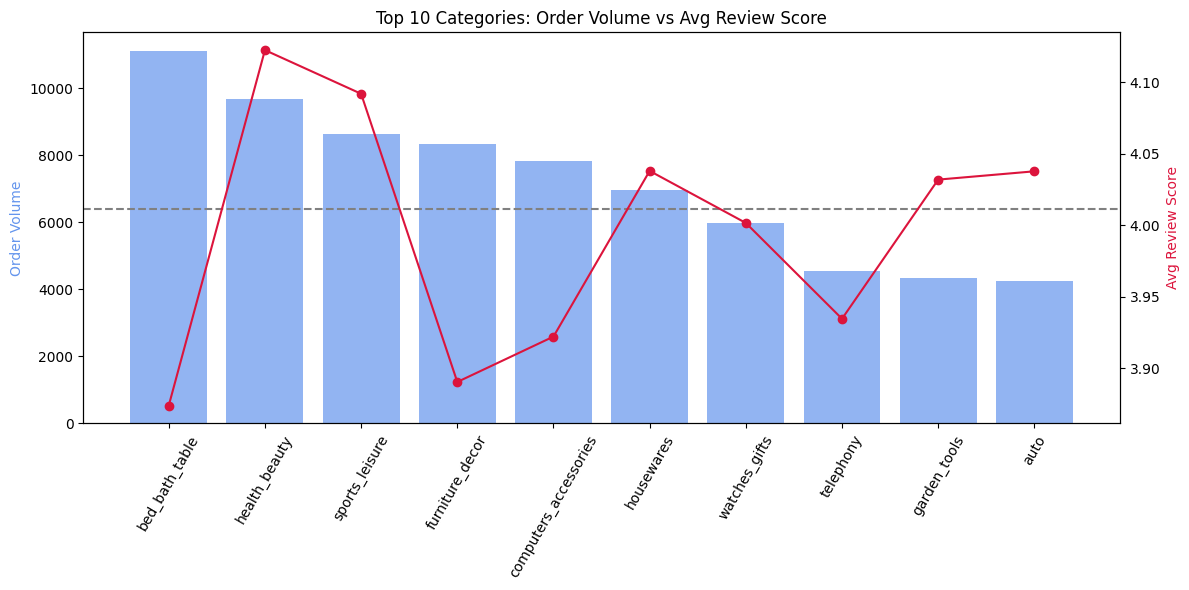

In [60]:
import matplotlib.pyplot as plt

top10 = cat_perf.head(10)

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(top10.index, top10['order_volume'], color='cornflowerblue', alpha=0.7)
ax1.set_ylabel('Order Volume', color='cornflowerblue')
ax1.tick_params(axis='x', rotation=60)

ax2 = ax1.twinx()
ax2.axhline(y=cat_perf['avg_review_score'].mean(), color='gray', linestyle='--', label='Platform Avg')
ax2.plot(top10.index, top10['avg_review_score'], color='crimson', marker='o')
ax2.set_ylabel('Avg Review Score', color='crimson')

plt.title('Top 10 Categories: Order Volume vs Avg Review Score')
plt.tight_layout()
plt.show()

### Insight: High-Volume Categories Underperform on Satisfaction

The platform's biggest-volume category, bed_bath_table (11,115 orders), scores below the
platform average (3.87 vs 4.01) — meaning the categories driving the most revenue are not
the categories delivering the best customer experience. Office furniture stands out as a
high-volume, low-satisfaction category (1,691 orders, 3.48 avg score) worth investigating
directly, likely tied to bulkier/heavier items facing more delivery or damage issues.
In contrast, niche categories like books and luggage consistently score above 4.3, though
at much lower volume.

#Section 3.5 — Core Question 5: Payment Behavior

In [61]:
print("Payment type distribution:")
print(master['main_payment_type'].value_counts())

pay_summary = master.groupby('main_payment_type').agg(
    order_count=('order_id', 'count'),
    avg_order_value=('total_payment_value', 'mean'),
    avg_installments=('max_installments', 'mean'),
    avg_review_score=('review_score', 'mean')
).sort_values('order_count', ascending=False)
print("\nPayment type summary:")
print(pay_summary)

installment_summary = master[master['main_payment_type']=='credit_card'].groupby('max_installments').agg(
    order_count=('order_id', 'count'),
    avg_order_value=('total_payment_value', 'mean'),
    avg_review_score=('review_score', 'mean')
)
print("\nCredit card installments vs order value/review:")
print(installment_summary.head(15))

corr = master[master['main_payment_type']=='credit_card'][['max_installments','total_payment_value','review_score']].corr()
print("\nCorrelation matrix (credit card orders):")
print(corr)

Payment type distribution:
main_payment_type
credit_card    76132
boleto         19784
voucher         1994
debit_card      1527
not_defined        3
Name: count, dtype: int64

Payment type summary:
                   order_count  avg_order_value  avg_installments  \
main_payment_type                                                   
credit_card              76132       166.565607          3.518691   
boleto                   19784       145.034435          1.000000   
voucher                   1994       120.661108          1.109328   
debit_card                1527       142.724158          1.000000   
not_defined                  3         0.000000          1.000000   

                   avg_review_score  
main_payment_type                    
credit_card                4.072519  
boleto                     4.071421  
voucher                    3.935807  
debit_card                 4.159790  
not_defined                1.666667  

Credit card installments vs order value/review:
  

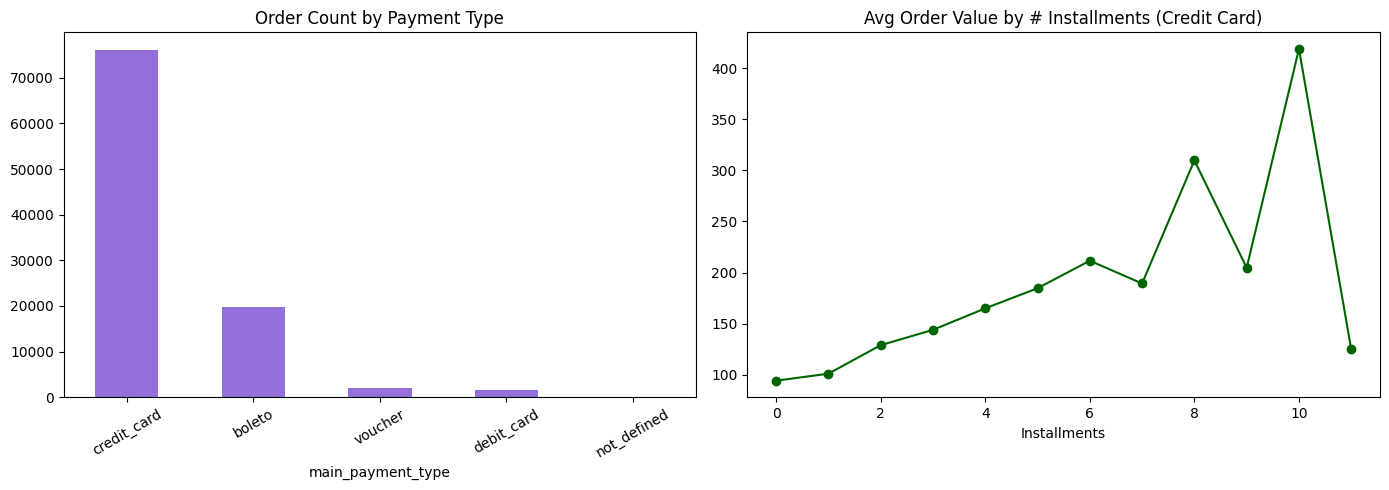

In [62]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

pay_summary['order_count'].plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Order Count by Payment Type')
axes[0].tick_params(axis='x', rotation=30)

installment_summary['avg_order_value'].head(12).plot(kind='line', marker='o', ax=axes[1], color='darkgreen')
axes[1].set_title('Avg Order Value by # Installments (Credit Card)')
axes[1].set_xlabel('Installments')

plt.tight_layout()
plt.show()

### Insight: Payment Behavior Reflects Purchase Size, Not Satisfaction

Credit card is the dominant payment method (77% of orders), and the number of installments
chosen correlates strongly with order value (r=0.37) — customers naturally finance larger
purchases over more installments, which is expected financial behavior rather than distress.
However, neither payment type nor number of installments shows any meaningful relationship
with review score (r=-0.04, and all payment types average within ~0.2 points of each other).
This means payment behavior is not a driver of customer satisfaction on this platform —
unlike delivery timing, which showed a far larger effect in Q2.

#Section 3.6 — Core Question 6: Root Cause Analysis

In [63]:
num_cols = ['delivery_days','delivery_delta_vs_estimate','total_price','total_freight',
            'n_items','max_installments','review_score']
corr = master[num_cols].corr()['review_score'].sort_values()
print("Correlation of factors with review_score:")
print(corr)

status_score = master.groupby('order_status')['review_score'].mean().sort_values()
print("\nAvg review score by order status:")
print(status_score)

item_score = master.groupby(master['n_items']>1)['review_score'].mean()
print("\nReview score: single item vs multi-item order")
print(item_score)

combo = master2.dropna(subset=['is_late']).groupby(['is_late','cross_state'])['review_score'].mean()
print("\nCombined effect: late delivery x cross-state shipping")
print(combo)

Correlation of factors with review_score:
delivery_days                -0.334905
delivery_delta_vs_estimate   -0.269508
n_items                      -0.116036
total_freight                -0.088938
total_price                  -0.040351
max_installments             -0.031552
review_score                  1.000000
Name: review_score, dtype: float64

Avg review score by order status:
order_status
processing     1.262458
unavailable    1.523810
invoiced       1.617834
canceled       1.796800
created        1.800000
shipped        1.986450
approved       2.500000
delivered      4.142416
Name: review_score, dtype: float64

Review score: single item vs multi-item order
n_items
False    4.124445
True     3.580231
Name: review_score, dtype: float64

Combined effect: late delivery x cross-state shipping
is_late  cross_state
False    False          4.325870
         True           4.252421
True     False          2.633397
         True           2.136391
Name: review_score, dtype: float64


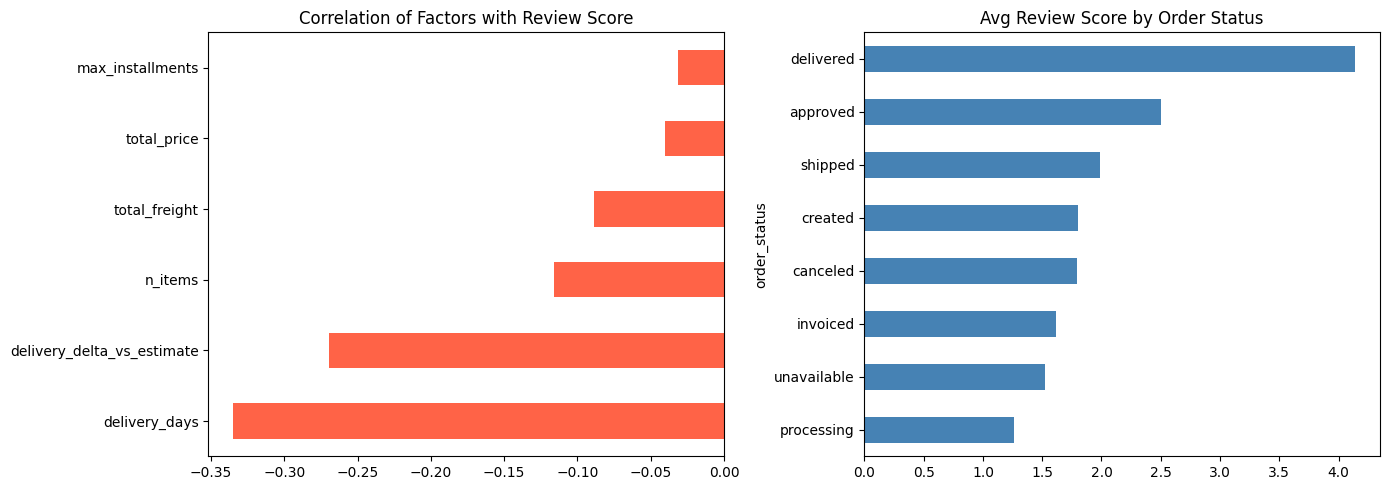

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

corr.drop('review_score').plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Correlation of Factors with Review Score')

status_score.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Avg Review Score by Order Status')

plt.tight_layout()
plt.show()

### Insight: Delivery Performance Is the Primary Driver of Dissatisfaction — Everything Else Is Secondary

Ranking all measured factors by their relationship with review score, delivery timing
dominates: both total delivery time (r=-0.33) and lateness versus the estimated date
(r=-0.27) are far stronger correlates of review score than any other factor — payment
behavior (r≈-0.03), price (r=-0.04), and even freight cost (r=-0.09) are comparatively
negligible. Orders that never reach 'delivered' status (shipped, canceled, unavailable)
score catastrophically low (1.3–2.0), though these represent a small share of volume (~2%).
Multi-item orders also underperform (3.58 vs 4.12), likely due to higher exposure to partial
delays. Critically, these factors compound: orders that are both late AND shipped cross-state
average just 2.14 — the worst outcome in the dataset — confirming that Olist's geographic
seller concentration (Q3) is not just a cost issue but a direct contributor to the delivery
delays that primarily drive customer dissatisfaction (Q2).

**Primary driver:** Delivery timing (lateness and total transit time).
**Secondary/contributing drivers:** Geographic distance (cross-state shipping), order
fulfillment failures (canceled/unavailable orders), and multi-item order complexity.
**Not meaningful drivers:** Payment type, installment count, product price.

## 4. Key Findings Summary

### Summary of Key Findings

1. **Trends**: Order volume and revenue grew steadily over the platform's history, while
   average review score stayed relatively stable — growth did not come at the cost of
   satisfaction on average.

2. **Delivery is the #1 driver of satisfaction**: Late deliveries drop average review score
   from 4.28 to 2.26, consistently across every major category and region.

3. **Geography compounds the problem**: Sellers are concentrated ~60% in São Paulo;
   cross-state shipments take nearly double the delivery time and score lower.

4. **Category performance varies**: High-volume categories like bed_bath_table underperform
   the platform average; office_furniture is a notable high-volume, low-satisfaction category.

5. **Payment behavior is not a driver**: Payment type and installment count show negligible
   correlation with review score.

6. **Root cause**: Delivery timing (both total transit time and lateness vs. estimate) is
   the dominant, primary driver of dissatisfaction. Cross-state shipping, order fulfillment
   failures, and multi-item orders are secondary contributors. Payment behavior and price
   are not meaningful drivers.

### Recommendations for Olist Leadership
- Prioritize logistics/carrier performance improvements, especially for cross-state shipments.
- Expand seller recruitment outside São Paulo to reduce shipping distance and cost.
- Investigate why bed_bath_table and office_furniture underperform despite high volume.
- Set more accurate estimated delivery dates — the fact that early delivery scores highest
  suggests some estimates may be padded, and precision itself could matter.